In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import seaborn as sns

In [28]:
df = pd.read_csv('social_anxiety_dataset/enhanced_anxiety_dataset.csv')
df.head()

,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10)
0,29,Female,Artist,6.0,2.7,181,10,Yes,No,10,114,14,4,No,Yes,3,Yes,7,5.0
1,46,Other,Nurse,6.2,5.7,200,8,Yes,Yes,1,62,23,2,Yes,No,2,No,8,3.0
2,64,Male,Other,5.0,3.7,117,4,No,Yes,1,91,28,3,No,No,1,Yes,1,1.0
3,20,Female,Scientist,5.8,2.8,360,6,Yes,No,4,86,17,3,No,No,0,No,1,2.0
4,49,Female,Other,8.2,2.3,247,4,Yes,No,1,98,19,4,Yes,Yes,1,No,3,1.0


### Data Visualization

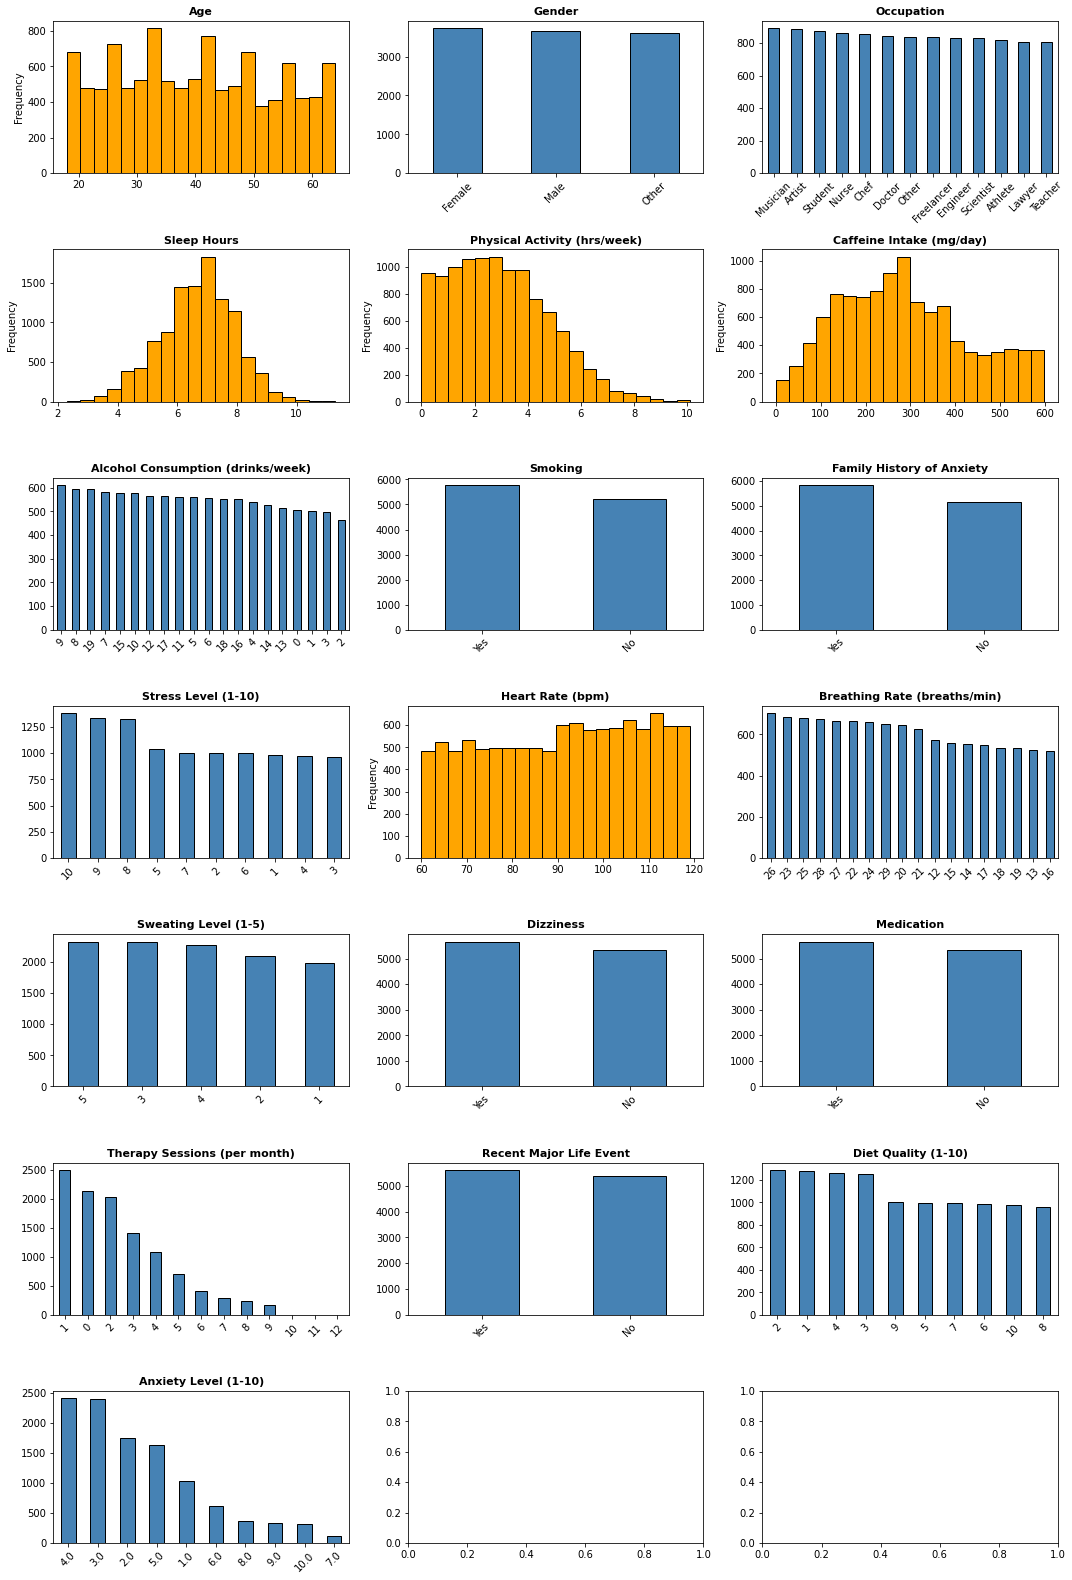

In [29]:
cols = df.columns.tolist()
n = len(cols)

fig, axes = plt.subplots(nrows=(n+2)//3, ncols=3, figsize=(18,(n//3+1)*4))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    if df[col].dtype == 'object' or len(df[col].unique()) <= 20:
        # categorical
        df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
        ax.tick_params(axis='x', rotation=45)
    else:
        # numeric
        df[col].plot(kind='hist', ax=ax, bins=20, color='orange', edgecolor='black')
        ax.tick_params(axis='x')
    
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
plt.subplots_adjust(hspace=0.5)


 ## Research Question: What are the key factors associated with social anxiety?

### 1. Descriptive Analysis: How does anxiety levels look like for each occupation?

In [30]:
occ_stats = (df.groupby('Occupation')['Anxiety Level (1-10)']
            .agg(['mean', 'std', 'count'])
            .sort_values(by='mean'))

print(occ_stats)

                mean       std  count
Occupation                           
Teacher     3.749690  2.036100    807
Other       3.764286  2.167406    840
Musician    3.789238  2.123139    892
Artist      3.796171  2.111361    888
Chef        3.840326  2.114882    858
Nurse       3.854820  2.142280    861
Athlete     3.871046  2.146388    822
Student     3.883827  2.142620    878
Freelancer  3.952267  2.152515    838
Scientist   4.062500  2.087943    832
Engineer    4.138055  2.055458    833
Doctor      4.199525  2.174460    842
Lawyer      4.206428  2.064710    809


Text(0.5, 1.0, 'Average Anxiety Level by Occupation')

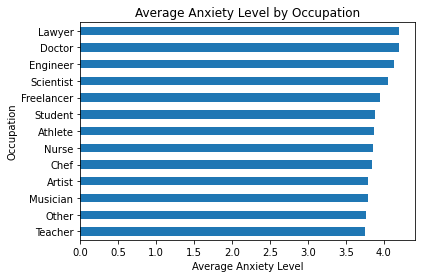

In [31]:
occ_stats['mean'].plot(kind='barh')
plt.xlabel('Average Anxiety Level')
plt.title ('Average Anxiety Level by Occupation')

### 2. One-way ANOVA: Do anxiety levels differ significantly across occupations?

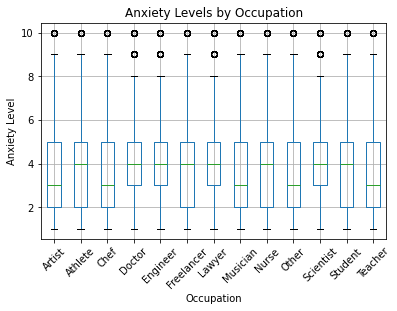

In [32]:
df.boxplot(column='Anxiety Level (1-10)', by='Occupation')

plt.xticks(rotation=45)
plt.title('Anxiety Levels by Occupation')
plt.suptitle('')
plt.ylabel('Anxiety Level')
plt.show()

In [33]:
anova_groups = [group['Anxiety Level (1-10)'].values for name, group in df.groupby('Occupation')]
anova_results = f_oneway(*anova_groups)
print(anova_results)

F_onewayResult(statistic=5.0803735560859415, pvalue=1.596907698727565e-08)


The p value is much smaller than 0.05 (p < 0.001), so at least one occupation has a significantly different mean anxiety level. Next, we run a post-hoc test to see which pair differs most significantly.

### 3. Post-hoc Test: Which two occupations differ the most in terms of anxiety levels?

In [34]:
tukey = pairwise_tukeyhsd(endog=df['Anxiety Level (1-10)'], groups=df['Occupation'], alpha=0.05)
tukey_results = tukey._results_table.data[1:]  # skip header

# find the pair with the biggest absolute difference
biggest = max(tukey_results, key=lambda x: abs(float(x[2])))
print(biggest)

['Lawyer', 'Teacher', -0.4567, 0.0011, -0.8059, -0.1076, True]


Among all occupation pairs, the largest difference in anxiety is between lawyers and teachers (0.4567). However, this difference is small on a 1–10 scale, so occupation does not seem to strongly affect anxiety. I will now look at other factors that may have a bigger impact on anxiety levels.

### 4. Multiple Linear Regression: How does each factor affects anxiety levels?

Here I do linear regression using all variables. I first convert categorical features into numeric forms using one-hot encoding and do one additional processing to convert boolean columns into binary values (0/1). 

In [40]:
df_num = pd.get_dummies(df, drop_first=True)
df_num = df_num.astype(float)
X = df_num.drop(columns=['Anxiety Level (1-10)'])
y = df_num['Anxiety Level (1-10)']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                             OLS Regression Results                             
Dep. Variable:     Anxiety Level (1-10)   R-squared:                       0.720
Model:                              OLS   Adj. R-squared:                  0.720
Method:                   Least Squares   F-statistic:                     941.6
Date:                  Tue, 12 May 2026   Prob (F-statistic):               0.00
Time:                          20:40:44   Log-Likelihood:                -16879.
No. Observations:                 11000   AIC:                         3.382e+04
Df Residuals:                     10969   BIC:                         3.405e+04
Df Model:                            30                                         
Covariance Type:              nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------

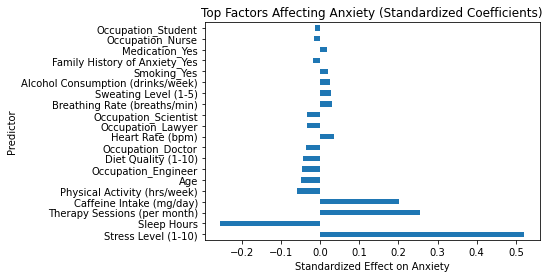

In [43]:
coef = model.params.drop('const')
X_no_const = X.drop(columns='const')
standardized_coef = coef * (X_no_const.std() / y.std())
top_coef = standardized_coef.sort_values(key=abs, ascending=False).head(20)
top_coef.plot(kind='barh')

plt.title('Top Factors Affecting Anxiety (Standardized Coefficients)')
plt.xlabel('Standardized Effect on Anxiety')
plt.ylabel('Predictor')
plt.show()

Because the variables are measured in different units, I use standardized coefficients to compare their relative importance. Stress level has the strongest positive association with anxiety, while sleep duration has the strongest negative association with anxiety.

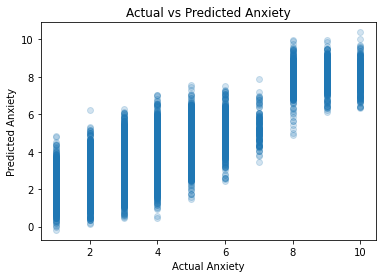

In [38]:
y_pred = model.predict(X)
plt.scatter(y, y_pred, alpha=0.2)
plt.xlabel('Actual Anxiety')
plt.ylabel('Predicted Anxiety')
plt.title('Actual vs Predicted Anxiety')
plt.show()

In [12]:
print('R^2', model.rsquared)
print('R^2_adjusted', model.rsquared_adj)
rmse = np.sqrt(mean_squared_error(y, y_pred))
print('RMSE:', rmse)

R^2 0.720292720735006
R^2_adjusted 0.7195277268086728
RMSE: 1.1225007560654958


The Actual vs Predicted Anxiety plot above shows a roughly linear relationship. The regression model has an R^2 of around 0.72, indicating it explains about 72% of the variance in anxiety levels. The small difference between R^2 and adjusted R^2 means that the model’s strong fit is not just due to the large number of predictors included. An RMSE of around 1.12 on the 10-point scale anxiety levels indicates good prediction accuracy.

### 5. Two-way ANOVA: Does anxiety differ by stress level group and sleep level group, and do they interact?

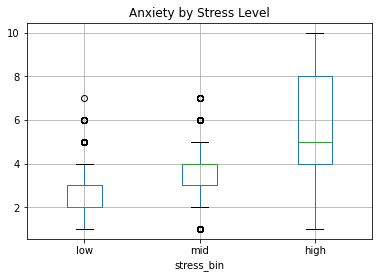

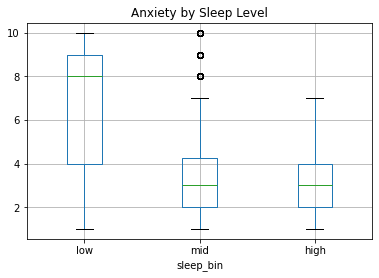

In [44]:
df['stress_bin'] = pd.cut(df['Stress Level (1-10)'], bins=3, labels=['low', 'mid', 'high'], ordered=True)
df['sleep_bin'] = pd.cut(df['Sleep Hours'], bins=3, labels=['low', 'mid', 'high'], ordered=True)

df.boxplot(column="Anxiety Level (1-10)", by="stress_bin")
plt.title("Anxiety by Stress Level")
plt.suptitle("")
plt.show()

df.boxplot(column="Anxiety Level (1-10)", by="sleep_bin")
plt.title("Anxiety by Sleep Level")
plt.suptitle("")
plt.show()

In [45]:
model = smf.ols('Q("Anxiety Level (1-10)") ~ C(stress_bin) + C(sleep_bin) + C(stress_bin):C(sleep_bin)', data=df).fit()
anova_results = anova_lm(model, typ=2)
print(anova_results)

                                  sum_sq       df            F         PR(>F)
C(stress_bin)               15300.104563      2.0  4679.469316   0.000000e+00
C(sleep_bin)                 6859.998312      2.0  2098.100145   0.000000e+00
C(stress_bin):C(sleep_bin)   2581.233934      4.0   394.729492  3.007432e-318
Residual                    17968.217965  10991.0          NaN            NaN


Both stress (F(2, 10991) = 4679.47, p < 0.001) and sleep (F(2, 10991) = 2098.10, p < 0.001) had significant main effects on anxiety, with stress being the stronger driver of the two. The significant interaction (F(4, 10991) = 394.73, p < 0.001) indicates that these effects are not independent, as the impact of stress on anxiety varies depending on sleep level.

/var/folders/7c/07jcs2r16n36xs7khhx49hw40000gn/T/ipykernel_35880/2697654284.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  interaction_means = (df.groupby(['stress_bin', 'sleep_bin'])['Anxiety Level (1-10)']


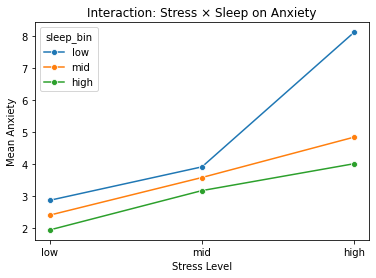

In [52]:
interaction_means = (df.groupby(['stress_bin', 'sleep_bin'])['Anxiety Level (1-10)']
    .mean()
    .reset_index()
    .sort_values(['stress_bin', 'sleep_bin']))

sns.lineplot(data=interaction_means, x='stress_bin', y='Anxiety Level (1-10)', 
             hue='sleep_bin', marker='o')

plt.title('Interaction: Stress × Sleep on Anxiety')
plt.xlabel('Stress Level')
plt.ylabel('Mean Anxiety')
plt.show()

The significant interaction indicates that sleep moderates the stress-anxiety relationship. Under low stress, sleep level has minimal impact on anxiety. However, under high stress, poor sleep is associated with substantially higher anxiety compared to adequate sleep, suggesting that sleep acts as a buffer against stress-induced anxiety.